# FPV attenuation factor analysis

Author: Sofia Midauar

Date: January 2025

In [1]:
import pandas as pd
import xarray as xr
import glob2 as glob
from scipy.interpolate import interp1d
import numpy as np
import os
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
# folder path to save figures
figs_path = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV'

In [4]:
# Creates list with depth of measurements
depth_obs = [0.5, 1, 2, 3, 4, 5, 6, 7]
depth_obs_str = []

for i in depth_obs:
    name = (str(i) + 'm')
    depth_obs_str.append(name)
    
depth_obs_str

['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']

In [19]:
(os.path.basename(names[file])[17:-13])

'curvgrid'

In [5]:
# Read folder locations for all the runs 
folder_runs = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/'
names = glob.glob(folder_runs + 'trim*.nc')

Dictionary_WT_underFPV = {}

for file in range(len(names)):
    names = glob.glob(folder_runs + 'trim*.nc')
    output = xr.open_dataset(names[file])
    output_temp_underFPV = output[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)
    output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR
    data_modelled = np.empty((len(output_temp_underFPV.time.values), 8))
    
    # calculates temperature per depth (matching measurements) for each timestep
    for i in range(len(output_temp_underFPV.time.values)):
        output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
        depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
        temp = output_temp_underFPV_t.R1.values # gets water temperature value
        time = output_temp_underFPV_t.time.values # gets timestep analysed
        temp = temp[depth > 0] # gets temperature values for depth > 0
        depth = depth[depth > 0] # gets depth values > 0
        f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
        data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep
    # Creates new dataframe with information on time and depth of the modelled temperature
    WT_underFPV_modelled = pd.DataFrame(data_modelled)
    times_t = pd.DataFrame(output_temp_underFPV.time.values)
    WT_underFPV_modelled['time'] = times_t
    WT_underFPV_modelled.set_index('time', inplace = True)
    WT_underFPV_modelled.columns = depth_obs_str
    # creates dictionary with all model outputs from the multiple attenuation factors
    name = (os.path.basename(names[file])[17:-13])
    Dictionary_WT_underFPV[name] = WT_underFPV_modelled.copy()

Dictionary_WT_underFPV

{'':                           0.5m         1m         2m         3m         4m  \
 time                                                                         
 2022-09-09 00:00:00  25.645449  25.591359  25.478496  25.359496  25.392140   
 2022-09-09 06:00:00  25.187235  25.193702  25.204337  25.210582  25.214235   
 2022-09-09 12:00:00  25.090880  25.097441  25.108323  25.114954  25.119029   
 2022-09-09 18:00:00  24.991331  24.998450  25.010141  25.017044  25.021255   
 2022-09-10 00:00:00  24.754751  24.760549  24.770210  24.776339  24.780721   
 ...                        ...        ...        ...        ...        ...   
 2024-03-14 00:00:00   4.240675   4.233353   4.205490   4.162800   4.106618   
 2024-03-14 06:00:00   4.780475   4.774330   4.594689   4.350998   4.218038   
 2024-03-14 12:00:00   4.500057   4.507368   4.509382   4.503699   4.489771   
 2024-03-14 18:00:00   4.314978   4.371799   4.411406   4.425842   4.432960   
 2024-03-15 00:00:00   4.290341   4.330673   4.3

# Compare runs

In [7]:
# Creates df with bias - one column per depth
runs_names = list(Dictionary_WT_underFPV.keys())
WT_noFPV_underFPV = Dictionary_WT_underFPV['curvgrid'].copy()
Dictionary_bias_underFPV = {}

# Add columns for other depths
for run in runs_names[2:]:
    temporary = Dictionary_WT_underFPV[run].copy()
    temp_bias = pd.DataFrame(temporary.index)
    temp_bias.set_index('time', inplace = True)
    for depth in range(0, len(depth_obs), 1):
        temp_bias['bias_' + depth_obs_str[depth]] = (temporary[temporary.columns[depth]] - 
                                                     WT_noFPV_underFPV[WT_noFPV_underFPV.columns[depth]])
    temp_bias['averaged_bias'] = temp_bias.mean(axis=1)
    Dictionary_bias_underFPV[(run + '_bias')] = temp_bias.copy()

Dictionary_bias_underFPV

{'eqgrid_bias':                      bias_0.5m   bias_1m   bias_2m   bias_3m   bias_4m  \
 time                                                                     
 2022-09-09 00:00:00   0.000000  0.000000  0.000000  0.000000  0.000000   
 2022-09-09 06:00:00  -0.004623 -0.004530 -0.004335 -0.004051 -0.003408   
 2022-09-09 12:00:00   0.004241  0.004729  0.005545  0.006072  0.006415   
 2022-09-09 18:00:00   0.011335  0.011701  0.012285  0.012596  0.012823   
 2022-09-10 00:00:00   0.005048  0.005242  0.005549  0.005709  0.005796   
 ...                        ...       ...       ...       ...       ...   
 2024-03-14 00:00:00   0.291128  0.312136  0.398934  0.373990  0.458131   
 2024-03-14 06:00:00   0.275729  0.287238  0.503712  0.405072  0.464061   
 2024-03-14 12:00:00   0.273667  0.266483  0.458964  0.414874  0.481263   
 2024-03-14 18:00:00   0.345928  0.359931  0.290629  0.422340  0.482686   
 2024-03-15 00:00:00   0.311650  0.335056  0.305833  0.405410  0.476910   
 
        

In [8]:
# Adjusts format for boxplot
runs = list(Dictionary_bias_underFPV.keys())
Dictionary_bias_boxplot_underFPV = {}

for run in range(0, len(runs),1):
    temp_completo = Dictionary_bias_underFPV[runs[run]].copy()
    for depth in range(len(depth_obs)+1):
        temp = pd.DataFrame(temp_completo[temp_completo.columns[depth]])
        temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
        try:
            temp['depth'] = depth_obs[depth]
        except:
            temp['depth'] = 'average'
        temp['run_ID'] = runs[run]
        if depth == 0:
            WT_bias_boxplot_underFPV = temp.copy()
        else:
            WT_bias_boxplot_underFPV = pd.concat([WT_bias_boxplot_underFPV, temp])
    
    Dictionary_bias_boxplot_underFPV[runs[run] + 'boxplot'] = WT_bias_boxplot_underFPV.copy()

Dictionary_bias_boxplot_underFPV

{'eqgrid_biasboxplot':                          bias    depth       run_ID
 time                                               
 2022-09-09 00:00:00  0.000000      0.5  eqgrid_bias
 2022-09-09 06:00:00 -0.004623      0.5  eqgrid_bias
 2022-09-09 12:00:00  0.004241      0.5  eqgrid_bias
 2022-09-09 18:00:00  0.011335      0.5  eqgrid_bias
 2022-09-10 00:00:00  0.005048      0.5  eqgrid_bias
 ...                       ...      ...          ...
 2024-03-14 00:00:00  0.388235  average  eqgrid_bias
 2024-03-14 06:00:00  0.404226  average  eqgrid_bias
 2024-03-14 12:00:00  0.403390  average  eqgrid_bias
 2024-03-14 18:00:00  0.405917  average  eqgrid_bias
 2024-03-15 00:00:00  0.398343  average  eqgrid_bias
 
 [19917 rows x 3 columns]}

In [9]:
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV[run].copy()
    temp = temp[temp['depth'] != 'average']
    if run == runs_bp[0]:
        joined_df_boxplot = temp.copy()
    else:
        joined_df_boxplot = pd.concat([joined_df_boxplot, temp])

joined_df_boxplot.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.000000,0.5,eqgrid_bias
2022-09-09 06:00:00,-0.004623,0.5,eqgrid_bias


In [10]:
runs_bp = list(Dictionary_bias_boxplot_underFPV.keys())

for run in runs_bp:
    temp = Dictionary_bias_boxplot_underFPV[run].copy()
    temp = temp[temp['depth'] == 'average']
    if run == runs_bp[0]:
        joined_df_bp_average = temp.copy()
    else:
        joined_df_bp_average = pd.concat([joined_df_bp_average, temp])

joined_df_bp_average.head(2)

,bias,depth,run_ID
time,,,
2022-09-09 00:00:00,0.000000,average,eqgrid_bias
2022-09-09 06:00:00,-0.001875,average,eqgrid_bias


In [15]:
Dictionary_WT_underFPV.keys()

dict_keys(['', 'curvgrid', 'eqgrid'])

In [20]:
compare = Dictionary_WT_underFPV['curvgrid'].copy()
compare = pd.DataFrame(compare['0.5m'])
compare.rename(columns = {'0.5m':'surf_curv'}, inplace = True)

temp = Dictionary_WT_underFPV['eqgrid'].copy()
temp = pd.DataFrame(temp['0.5m'])
temp.rename(columns = {'0.5m':'surf_eqgrid'}, inplace = True)

compare['surf_eqgrid'] = temp['surf_eqgrid']
compare

,surf_curv,surf_eqgrid
time,,
2022-09-09 00:00:00,25.645449,25.645449
2022-09-09 06:00:00,25.192780,25.188157
2022-09-09 12:00:00,25.147041,25.151281
2022-09-09 18:00:00,25.103054,25.114390
2022-09-10 00:00:00,24.849414,24.854462
...,...,...
2024-03-14 00:00:00,7.634906,7.926034
2024-03-14 06:00:00,8.725358,9.001087
2024-03-14 12:00:00,8.422413,8.696081


<Axes: xlabel='time'>

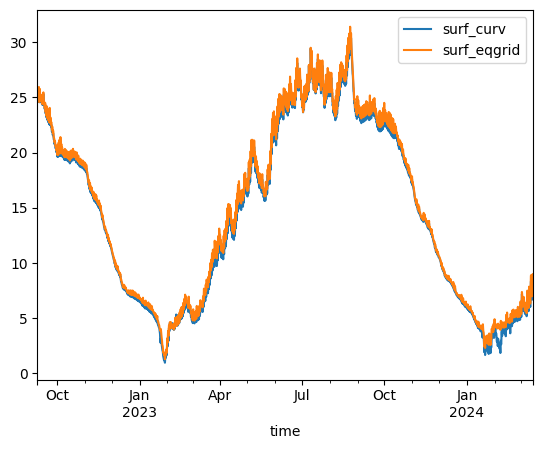

In [21]:
compare.plot()

In [25]:
compare['difference'] = (compare['surf_eqgrid'] - compare['surf_curv'])
compare['dif_%'] = (compare['difference'] / compare['surf_eqgrid']) * 100
compare

,surf_curv,surf_eqgrid,difference,dif_%
time,,,,
2022-09-09 00:00:00,25.645449,25.645449,0.000000,0.000000
2022-09-09 06:00:00,25.192780,25.188157,-0.004623,-0.018354
2022-09-09 12:00:00,25.147041,25.151281,0.004241,0.016860
2022-09-09 18:00:00,25.103054,25.114390,0.011335,0.045134
2022-09-10 00:00:00,24.849414,24.854462,0.005048,0.020310
...,...,...,...,...
2024-03-14 00:00:00,7.634906,7.926034,0.291128,3.673062
2024-03-14 06:00:00,8.725358,9.001087,0.275729,3.063286
2024-03-14 12:00:00,8.422413,8.696081,0.273667,3.147019


In [27]:
compare['dif_%'].mean()

3.9822194512691427

# Plots

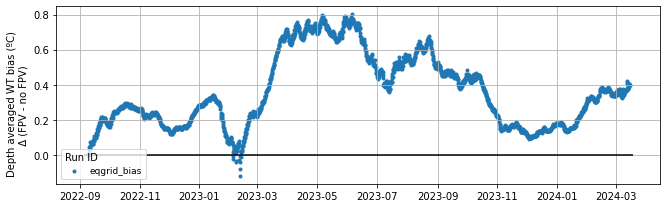

In [11]:
# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)
 
legends = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']
runs = list(Dictionary_bias_underFPV.keys())

for run in range(0, len(runs), 1):
    temp_plot = Dictionary_bias_underFPV[runs[run]].copy()
    ax.scatter(temp_plot.index, temp_plot[temp_plot.columns[-1]],
               marker = '.', color = pal.as_hex()[run], zorder = 1, 
               label = runs[run])
    ax.hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax.grid(True, zorder = -1)

ax.legend(title = "Run ID", loc="lower left", ncol = 1, fontsize = 9, 
               frameon = True, columnspacing = 0.01)._legend_box.align = "left"

# ax.set_ylim(-0.5,0.6)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Depth averaged WT bias (ºC)\n          Δ (FPV - no FPV)', va='center', rotation='vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_depthaveraged.jpeg', dpi = 300, bbox_inches = 'tight')

plt.show();

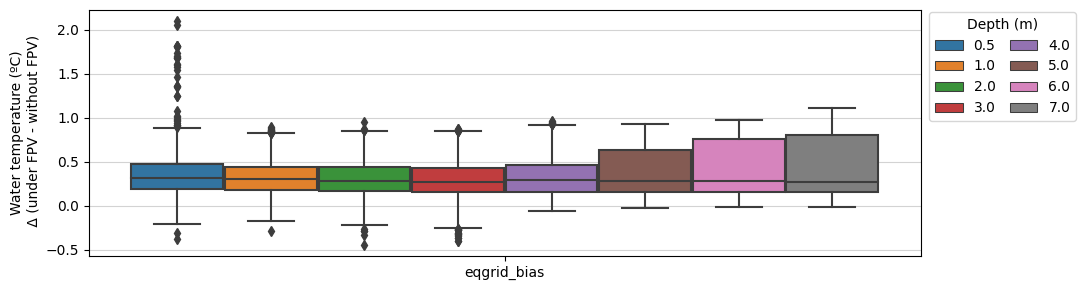

In [12]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [11,3])

pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "run_ID", y = "bias", 
            data = joined_df_boxplot,
            width = 0.9, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax, hue = 'depth')

ax.set_xticks(list(range(0, len(runs), 1)), runs,
              fontsize = 10) 
ax.xaxis.set_label_text("")
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)

ax.yaxis.set_label_text(u'Water temperature (ºC)\n Δ (under FPV - without FPV)', fontsize = 10)
ax.legend(title = "Depth (m)", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1, bbox_to_anchor=(1.195, 1.02))

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_perdepth_boxplot.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

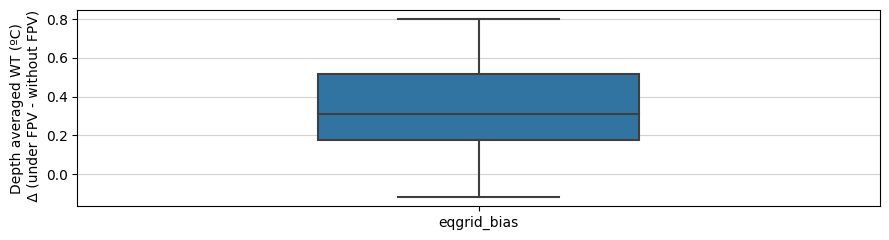

In [14]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,2.5])

pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "run_ID", y = "bias", 
            data = joined_df_bp_average,
            width = 0.4, boxprops = {'zorder': 2}, palette = pal[0:9], ax = ax)

ax.set_xticks(list(range(0, len(runs), 1)), runs,
              fontsize = 10) 
ax.xaxis.set_label_text("")
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)

ax.yaxis.set_label_text(u'Depth averaged WT (ºC)\n Δ (under FPV - without FPV)', fontsize = 10)

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'bias_WT_depthaveraged_boxplot.jpeg', dpi = 300, bbox_inches = 'tight')
plt.show();

# Obsolete

In [6]:
output = xr.open_dataset(output_files[0] + 'trim-FPV_cover49_eqgrid_factor045.nc')

In [8]:
# Creates file with temperature data for specific location
# R1: water temperature | ZK_LYR: Vertical coordinates of layer centres | S1: Water-level in zeta point
output_temp_underFPV = output[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)

In [9]:
# Creates variable with depth of zeta point (S1: Water-level in zeta point - ZK_LYR: Vertical coordinates of layer centres)
output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR

In [10]:
# Creates empty array with dimensions matching (timesteps, measurement points length)
data_modelled = np.empty((len(output_temp_underFPV.time.values), 8))

# calculates temperature per depth (matching measurements) for each timestep
for i in range(len(output_temp_underFPV.time.values)):
    output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
    depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
    temp = output_temp_underFPV_t.R1.values # gets water temperature value
    time = output_temp_underFPV_t.time.values # gets timestep analysed
    temp = temp[depth > 0] # gets temperature values for depth > 0
    depth = depth[depth > 0] # gets depth values > 0
    f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
    data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep

In [11]:
# Creates new dataframe with information on time and depth of the modelled temperature
WT_underFPV_modelled = pd.DataFrame(data_modelled)
times_t = pd.DataFrame(output_temp_underFPV.time.values)
WT_underFPV_modelled['time'] = times_t
WT_underFPV_modelled.set_index('time', inplace = True)
WT_underFPV_modelled.columns = depth_obs_str
WT_underFPV_modelled.head(2)

,0.5m,1m,2m,3m,4m,5m,6m,7m
time,,,,,,,,
2022-09-09 00:00:00,25.645449,25.591359,25.478496,25.359496,25.392140,25.175947,24.767722,24.473604
2022-09-09 06:00:00,25.192474,25.198753,25.209063,25.215055,25.218371,25.217465,24.800751,24.486867
